<a href="https://colab.research.google.com/github/msolowes-star/DI-Bootcamp/blob/main/Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Loading and Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import skew, kurtosis, pearsonr, f_oneway

In [2]:
url = "https://raw.githubusercontent.com/devtlv/MiniProject-DataAnalysis-W6D5-Mobile_Price_Classification/main/train.csv"

df = pd.read_csv(url)

df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [3]:
df.shape

(2000, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [5]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [6]:
df.isnull().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


In [7]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


The dataset contains 2,000 observations and 21 columns. Twenty columns represent mobile-phone characteristics, while price_range is the target variable. All 21 columns contain 2,000 non-null observations, indicating that there are no missing values in the dataset. The dataset consists entirely of numerical variables, with 19 integer columns and 2 floating-point columns. Several categorical characteristics, such as Bluetooth, dual SIM, 4G, 3G, touchscreen, and Wi-Fi, are already encoded numerically as binary variables.

Data Cleaning and Preprocessing

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
df.isnull().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


No missing values were detected, so imputation was not required.

In [10]:
df.dtypes.value_counts()

,count
int64,19
float64,2


In [11]:
df.select_dtypes(include="object").columns

Index([], dtype='object')

In [12]:
categorical_cols = df.select_dtypes(include="object").columns

print("Categorical columns:", list(categorical_cols))

Categorical columns: []


All variables were already stored numerically, so categorical encoding was not necessary. Several features are binary indicators encoded as 0 and 1.

Statistical Analysis with NumPy and SciPy

In [13]:
features = df.drop(columns="price_range")

stats_summary = pd.DataFrame({
    "Mean": features.mean(),
    "Median": features.median(),
    "Mode": features.mode().iloc[0],
    "Min": features.min(),
    "Max": features.max(),
    "Range": features.max() - features.min(),
    "Variance": features.var(),
    "Std Dev": features.std(),
    "Skewness": features.apply(skew),
    "Kurtosis": features.apply(kurtosis)
})

stats_summary

,Mean,Median,Mode,Min,Max,Range,Variance,Std Dev,Skewness,Kurtosis
battery_power,1238.51850,1226.0,618.0,501.0,1998.0,1497.0,1.930884e+05,439.418206,0.031875,-1.224084
blue,0.49500,0.0,0.0,0.0,1.0,1.0,2.501001e-01,0.500100,0.020001,-1.999600
clock_speed,1.52225,1.5,0.5,0.5,3.0,2.5,6.658629e-01,0.816004,0.177951,-1.323109
dual_sim,0.50950,1.0,1.0,0.0,1.0,1.0,2.500348e-01,0.500035,-0.038007,-1.998555
fc,4.30950,3.0,0.0,0.0,19.0,19.0,1.884813e+01,4.341444,1.019046,0.273386
four_g,0.52150,1.0,1.0,0.0,1.0,1.0,2.496626e-01,0.499662,-0.086080,-1.992590
int_memory,32.04650,32.0,27.0,2.0,64.0,62.0,3.292670e+02,18.145715,0.057846,-1.216034
m_dep,0.50175,0.5,0.1,0.1,1.0,0.9,8.318353e-02,0.288416,0.089015,-1.274164
mobile_wt,140.24900,141.0,182.0,80.0,200.0,120.0,1.253136e+03,35.399655,0.006553,-1.210351
n_cores,4.52050,4.0,4.0,1.0,8.0,7.0,5.234197e+00,2.287837,0.003625,-1.229676


Central tendency measures describe the typical value of each feature, while variance, range, and standard deviation describe how widely values are distributed. Skewness indicates whether a distribution is symmetric or weighted toward higher or lower values, while kurtosis helps describe the heaviness of the distribution's tails.

Compare Average RAM Across Price Groups

In [14]:
df.groupby("price_range")["ram"].mean()

,ram
price_range,
0,785.314
1,1679.490
2,2582.816
3,3449.232


In [15]:
group0 = df[df["price_range"] == 0]["ram"]
group1 = df[df["price_range"] == 1]["ram"]
group2 = df[df["price_range"] == 2]["ram"]
group3 = df[df["price_range"] == 3]["ram"]

In [16]:
f_stat, p_value = f_oneway(
    group0,
    group1,
    group2,
    group3
)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 3520.1108238957563
P-value: 0.0


In [17]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("Mean RAM differs significantly across price groups.")
else:
    print("Fail to reject the null hypothesis.")

Reject the null hypothesis.
Mean RAM differs significantly across price groups.


A one-way ANOVA was performed to determine whether average RAM differed significantly among the four mobile-phone price categories. The null hypothesis stated that mean RAM was equal across all four price groups, while the alternative hypothesis stated that at least one group had a different mean RAM.

The ANOVA produced an F-statistic of approximately 3520.11 and a p-value reported as 0.0. This indicates an extremely small p-value rather than a literal probability of zero. Since the p-value is far below the significance level of 0.05, the null hypothesis is rejected.

Therefore, there is very strong statistical evidence that average RAM differs across mobile-phone price categories. This suggests that RAM is likely an important feature associated with mobile price classification.

Correlation Between Features and Price Range

In [18]:
correlations = df.corr(numeric_only=True)["price_range"].sort_values(ascending=False)

correlations

,price_range
price_range,1.000000
ram,0.917046
battery_power,0.200723
px_width,0.165818
px_height,0.148858
int_memory,0.044435
sc_w,0.038711
pc,0.033599
three_g,0.023611
sc_h,0.022986


In [19]:
ram_corr, ram_p = pearsonr(df["ram"], df["price_range"])

print("RAM correlation:", ram_corr)
print("RAM p-value:", ram_p)

RAM correlation: 0.917045736264991
RAM p-value: 0.0


In [20]:
battery_corr, battery_p = pearsonr(
    df["battery_power"],
    df["price_range"]
)

print("Battery correlation:", battery_corr)
print("Battery p-value:", battery_p)

Battery correlation: 0.200722612113731
Battery p-value: 1.2648542392221185e-19


In [21]:
px_corr, px_p = pearsonr(
    df["px_width"],
    df["price_range"]
)

print("Pixel width correlation:", px_corr)
print("Pixel width p-value:", px_p)

Pixel width correlation: 0.16581750172625512
Pixel width p-value: 8.478968798292687e-14


Pearson correlation analysis was performed to examine the relationships between selected mobile-phone features and price range. RAM demonstrated a very strong positive correlation with price range (r = 0.917), indicating that phones with greater RAM tend to belong to substantially higher price categories.

Battery power showed a weaker positive correlation of approximately r = 0.201, while pixel width showed a weak positive correlation of approximately r = 0.166. The p-values for all three correlations were well below 0.05, indicating that these relationships are statistically significant.

Among the features examined, RAM is by far the strongest determinant of mobile price classification. However, correlation represents association and does not by itself establish causation.

Find Strongest Correlations

In [22]:
target_corr = (
    df.corr(numeric_only=True)["price_range"]
    .drop("price_range")
    .sort_values(key=abs, ascending=False)
)

target_corr.head(10)

,price_range
ram,0.917046
battery_power,0.200723
px_width,0.165818
px_height,0.148858
int_memory,0.044435
sc_w,0.038711
pc,0.033599
touch_screen,-0.030411
mobile_wt,-0.030302
three_g,0.023611


The correlation analysis reveals that RAM is by far the feature most strongly associated with mobile price range, with a correlation coefficient of approximately 0.917. This represents a very strong positive relationship, meaning that phones with greater RAM tend to fall into higher price categories.

Battery power had the second-highest correlation at approximately 0.201, followed by pixel width (0.166) and pixel height (0.149). These relationships are positive but considerably weaker than the relationship between RAM and price range.

Most of the remaining features had correlations close to zero, suggesting relatively weak individual linear relationships with price classification. Overall, the analysis indicates that RAM is the dominant individual feature associated with price category in this dataset.

Data Visualization with Matplotlib

Histogram of RAM

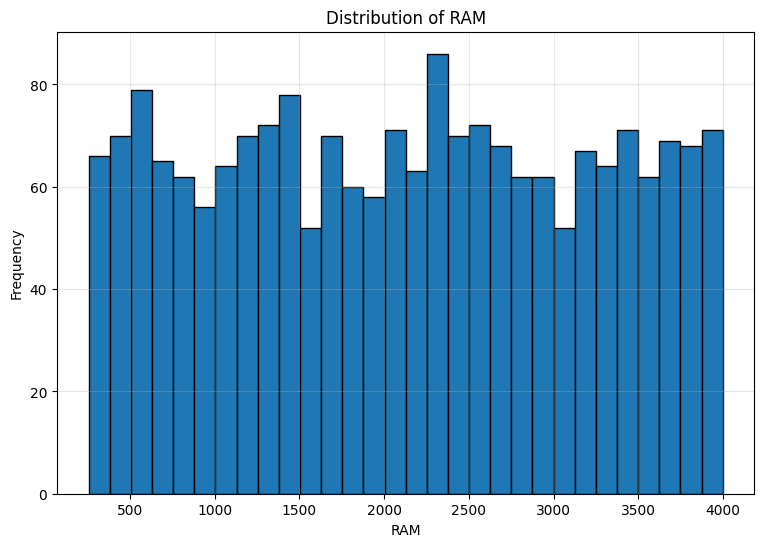

In [23]:
plt.figure(figsize=(9, 6))

plt.hist(
    df["ram"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of RAM")
plt.xlabel("RAM")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.show()

The histogram shows that RAM values are distributed relatively evenly across the dataset, ranging from approximately 250 MB to 4,000 MB. There is no strong evidence of substantial positive or negative skewness, and phones with both low and high RAM capacities are well represented. This broad distribution makes RAM particularly useful for examining its relationship with mobile price classification.

Histogram of Battery Power

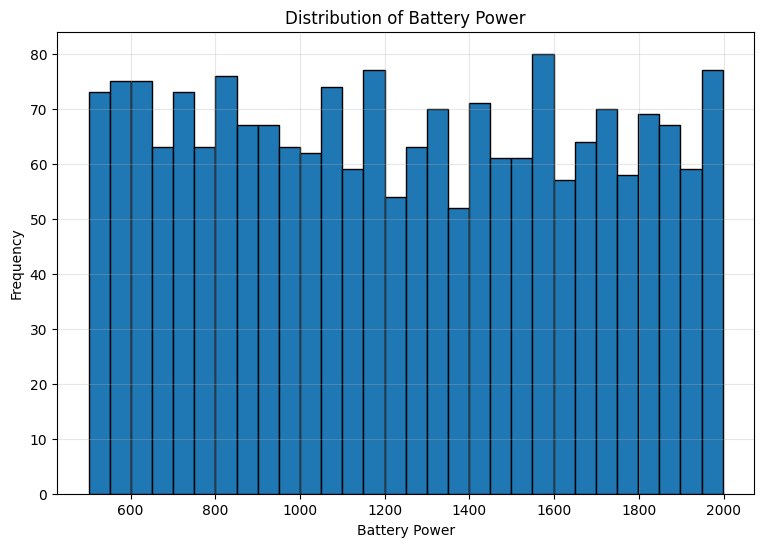

In [24]:
plt.figure(figsize=(9, 6))

plt.hist(
    df["battery_power"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Battery Power")
plt.xlabel("Battery Power")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.show()

The battery power distribution is relatively even across the observed range of approximately 500 to 2,000. There is no obvious strong skewness, suggesting that the dataset contains a broad representation of phones with different battery capacities. Although battery power has a statistically significant relationship with price range, its correlation of approximately 0.201 indicates that the relationship is relatively weak compared with RAM.

Scatter Plot: RAM vs Price Range

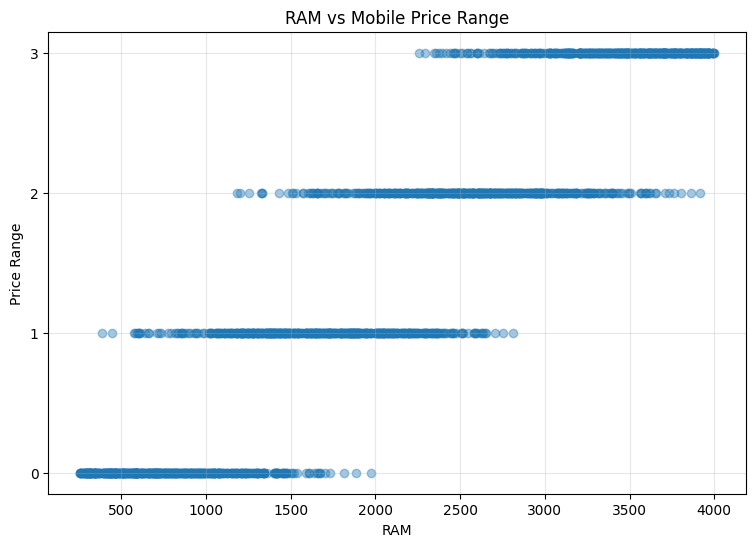

In [25]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["ram"],
    df["price_range"],
    alpha=0.4
)

plt.title("RAM vs Mobile Price Range")
plt.xlabel("RAM")
plt.ylabel("Price Range")
plt.yticks([0, 1, 2, 3])

plt.grid(alpha=0.3)
plt.show()

The scatter plot demonstrates a strong positive relationship between RAM and mobile price range. Lower-priced phones are concentrated at lower RAM values, while higher-priced phones generally contain substantially more RAM. Although some overlap exists between neighboring price categories, there is a clear upward progression in RAM as price range increases. This visual pattern strongly supports the Pearson correlation result of 0.917, indicating that RAM is the feature most strongly associated with mobile price classification in this dataset.

Box Plot of RAM by Price Range

/tmp/ipykernel_2551/1675082227.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


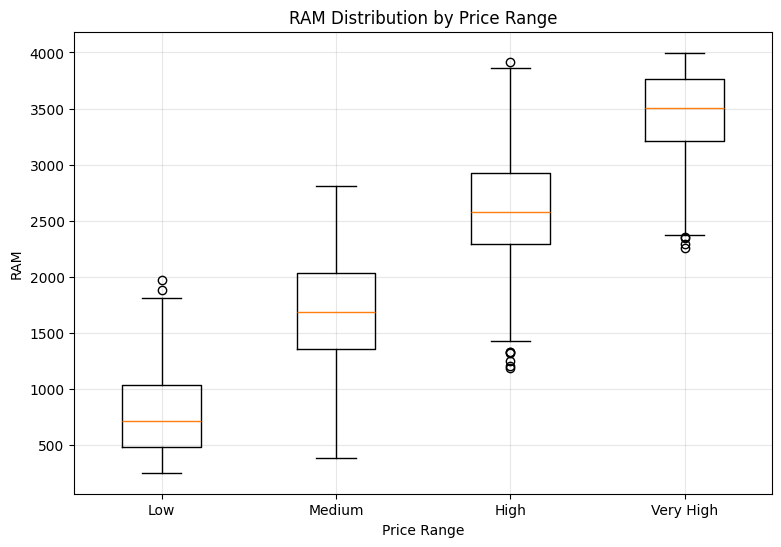

In [26]:
ram_groups = [
    df[df["price_range"] == 0]["ram"],
    df[df["price_range"] == 1]["ram"],
    df[df["price_range"] == 2]["ram"],
    df[df["price_range"] == 3]["ram"]
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    ram_groups,
    labels=["Low", "Medium", "High", "Very High"]
)

plt.title("RAM Distribution by Price Range")
plt.xlabel("Price Range")
plt.ylabel("RAM")

plt.grid(alpha=0.3)
plt.show()

The box plot demonstrates a clear increase in RAM as mobile price category rises. The median RAM increases consistently from the low-price category through the very-high-price category. Although some overlap and outliers are present, the distributions show substantial separation between price groups.

This visualization supports both the strong positive correlation between RAM and price range (r = 0.917) and the one-way ANOVA result (F = 3520.11, p < 0.05). Together, these results provide strong evidence that RAM is an important feature associated with mobile price classification.

Battery Power by Price Range

/tmp/ipykernel_2551/1444430128.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


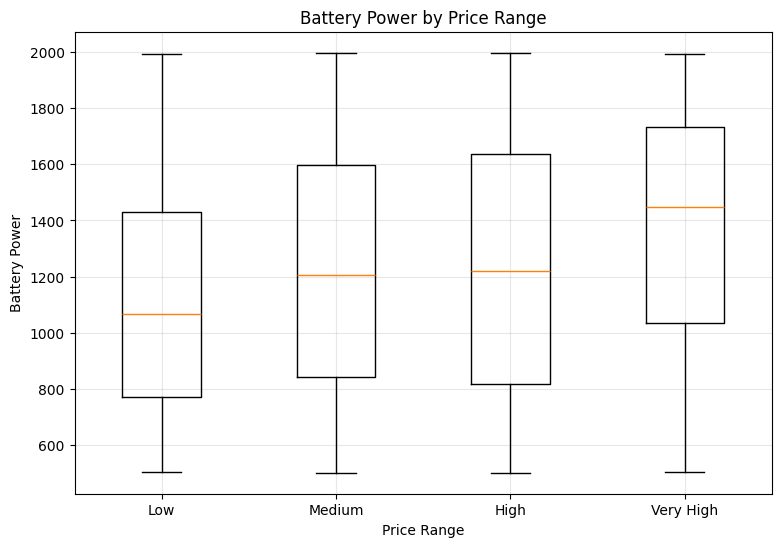

In [27]:
battery_groups = [
    df[df["price_range"] == 0]["battery_power"],
    df[df["price_range"] == 1]["battery_power"],
    df[df["price_range"] == 2]["battery_power"],
    df[df["price_range"] == 3]["battery_power"]
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    battery_groups,
    labels=["Low", "Medium", "High", "Very High"]
)

plt.title("Battery Power by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Battery Power")

plt.grid(alpha=0.3)
plt.show()

Correlation Heatmap with Matplotlib

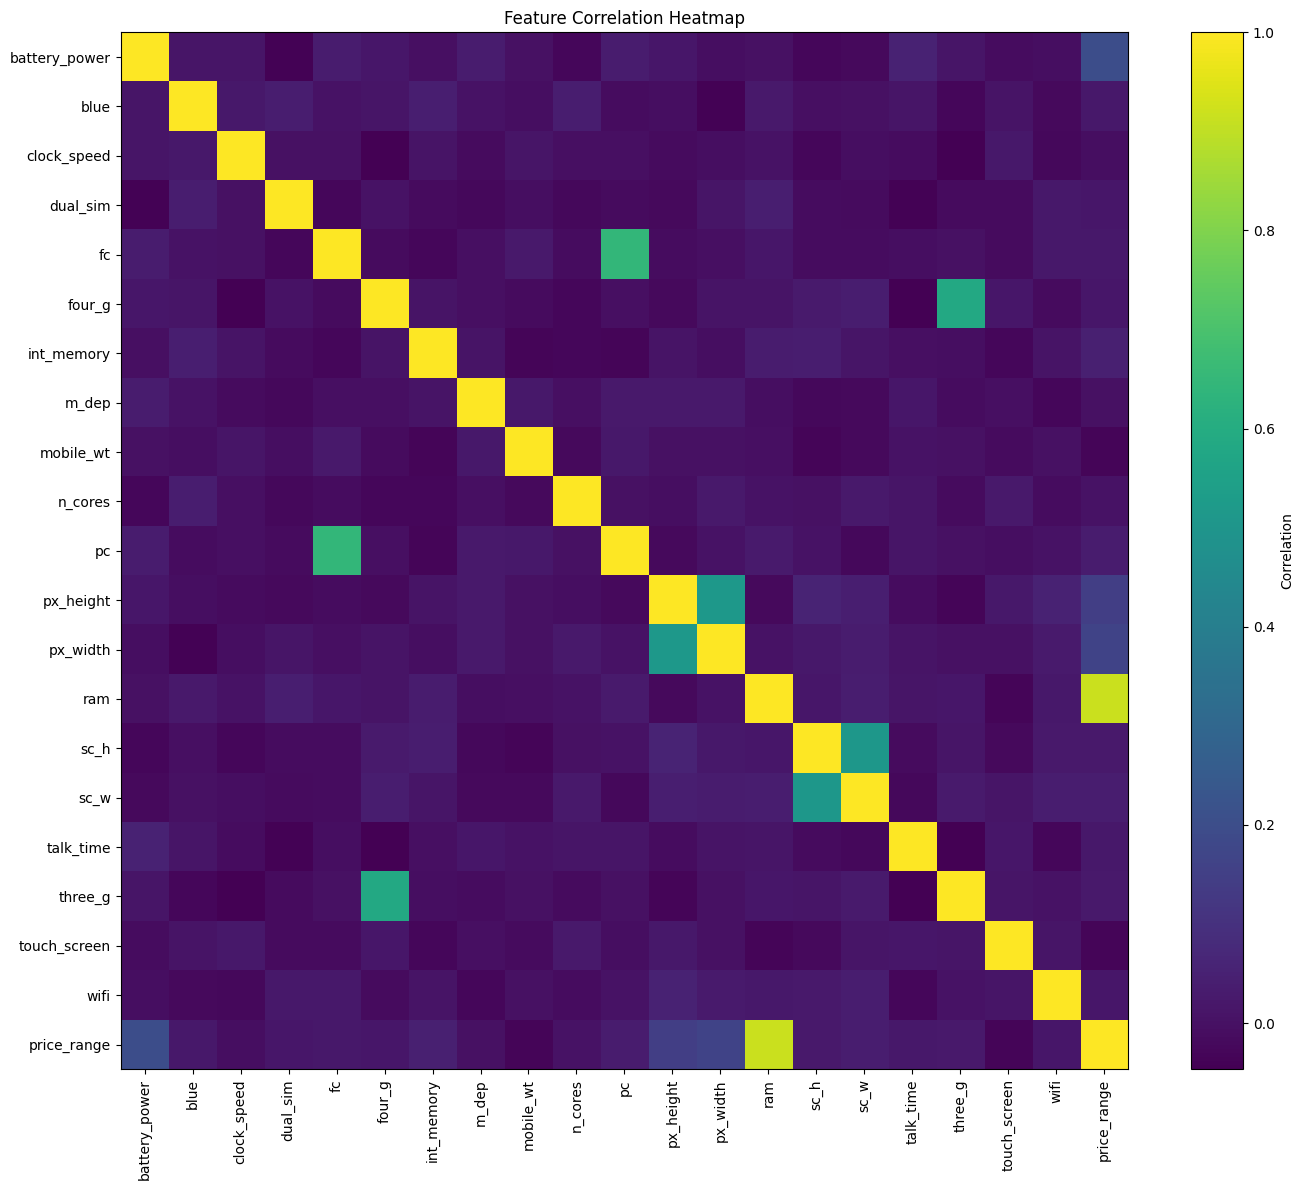

In [28]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(14, 12))

plt.imshow(
    corr_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()

plt.show()

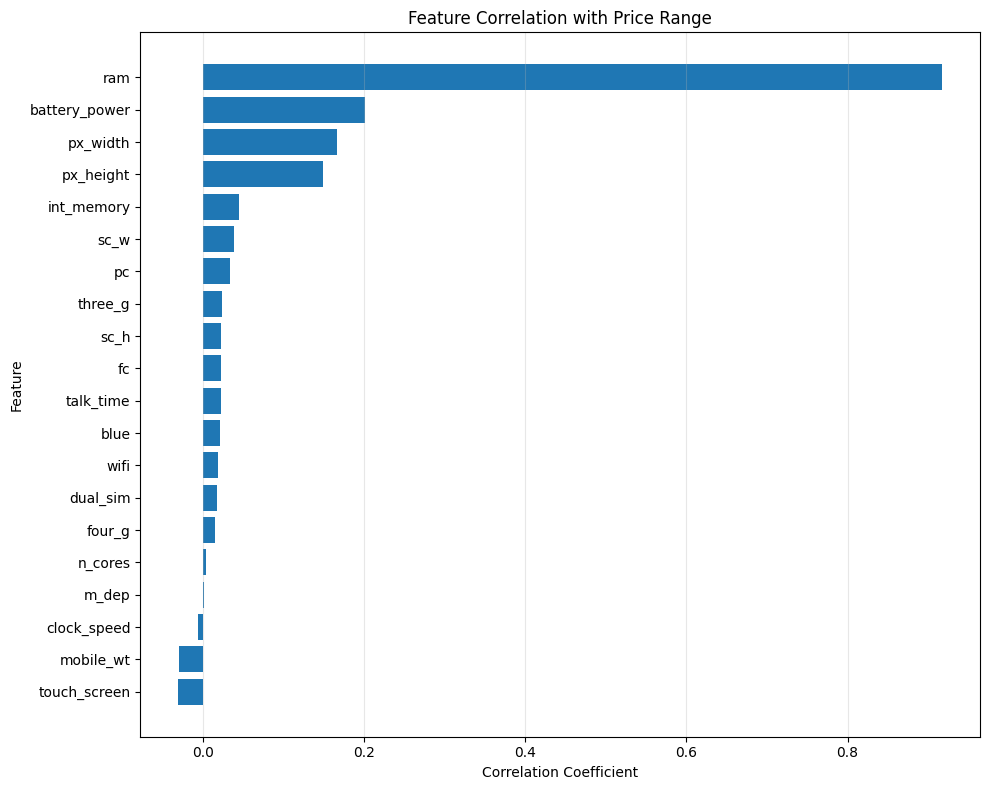

In [29]:
target_corr_sorted = (
    df.corr(numeric_only=True)["price_range"]
    .drop("price_range")
    .sort_values()
)

plt.figure(figsize=(10, 8))

plt.barh(
    target_corr_sorted.index,
    target_corr_sorted.values
)

plt.title("Feature Correlation with Price Range")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

The correlation heatmap provides an overview of the relationships among all numerical variables in the dataset. Most feature pairs show relatively weak correlations, indicating that many mobile-phone characteristics provide distinct information.

Several stronger relationships are visible, including those between pixel height and pixel width, front and primary camera specifications, screen height and screen width, and 3G and 4G connectivity. Most importantly, RAM displays a particularly strong relationship with the target variable price_range, consistent with the Pearson correlation coefficient of approximately 0.917.

Overall, the heatmap reinforces the finding that RAM has the strongest individual linear association with mobile price classification among the features analyzed.

Additional SciPy Analysis

In [30]:
important_features = [
    "ram",
    "battery_power",
    "px_height",
    "px_width",
    "mobile_wt"
]

for col in important_features:
    print(f"\n{col}")
    print("Skewness:", skew(df[col]))
    print("Kurtosis:", kurtosis(df[col]))


ram
Skewness: 0.006623063336208135
Kurtosis: -1.1919338732410705

battery_power
Skewness: 0.03187454295305568
Kurtosis: -1.224084165725428

px_height
Skewness: 0.6657714484857727
Kurtosis: -0.3180748831869664

px_width
Skewness: 0.014776380851328284
Kurtosis: -1.1860407916882159

mobile_wt
Skewness: 0.0065532377855500356
Kurtosis: -1.2103511507234548


Insight Synthesis and Conclusion

This analysis examined the statistical characteristics of mobile phone features and their relationship with price classification. The dataset contained 2,000 observations and 21 variables and was complete, with no missing values in any of the columns. All variables were already numerical, so minimal preprocessing was required.

Descriptive statistical analysis showed substantial variation across features such as RAM, battery power, camera specifications, internal memory, pixel resolution, and screen characteristics. Histograms showed that RAM and battery power were distributed relatively evenly across their observed ranges, without evidence of extreme skewness.

One of the clearest findings was the relationship between RAM and mobile price range. A one-way ANOVA comparing RAM across the four price categories produced an F-statistic of approximately 3520.11 with p < 0.001. Therefore, the null hypothesis that mean RAM is equal across all four price categories was rejected. This provides very strong statistical evidence that RAM differs significantly among mobile price classes.

The correlation analysis further demonstrated the importance of RAM. RAM had a very strong positive correlation of approximately 0.917 with price range, making it by far the strongest individual association identified in the analysis. Battery power had the next-highest correlation at approximately 0.201, followed by pixel width at 0.166 and pixel height at 0.149. Most remaining features showed relatively weak individual linear relationships with price range.

The visualizations strongly supported these statistical findings. The RAM scatter plot showed that phones generally moved into higher price categories as RAM increased, while the box plot demonstrated a clear increase in median RAM from the low-price category through the very-high-price category. The correlation heatmap also highlighted the unusually strong relationship between RAM and price range compared with most other features.

Overall, RAM appears to be the most important individual feature associated with mobile price classification in this dataset. Battery power and pixel resolution also appear to contribute, but their individual relationships with price range are considerably weaker. These findings demonstrate the value of combining descriptive statistics, hypothesis testing, correlation analysis, and visualization when identifying patterns in a dataset. However, these relationships should be interpreted as associations rather than proof that any individual feature directly causes a phone to have a particular price.

Rwflection

One challenge in this project was deciding which statistical methods were appropriate for different types of variables. For example, price_range is an ordinal categorical target, while the input features include both continuous and binary variables. This required careful interpretation of correlation coefficients and hypothesis-testing results.

Another challenge was analyzing a dataset with many different features. Creating a statistical summary containing measures such as mean, median, mode, variance, standard deviation, skewness, and kurtosis made it easier to systematically compare the characteristics of each variable.

Interpreting extremely small p-values was also an important part of the analysis. For example, the ANOVA test returned a p-value displayed as 0.0. I learned that this does not mean the probability is literally zero, but rather that the value is extremely small due to numerical precision. This result provided very strong evidence that RAM differs significantly across the four price categories.

The project also demonstrated the importance of combining statistical analysis with visualization. The strong relationship between RAM and price range was identified statistically through correlation and ANOVA, but the scatter plot and box plot made this relationship much easier to understand visually.

Overall, this challenge strengthened my understanding of Pandas, NumPy, SciPy, and Matplotlib and how they can be combined for exploratory data analysis and statistical inference. It also improved my ability to interpret statistical results rather than simply calculate them.